# LoRA Fine-Tuning

In this notebook we will implement [Low-Rank Adaptation, LoRA](https://arxiv.org/abs/2106.09685), as an approach for fine-tuning.

This notebook is inspired by Appendix E in of [Build A Larger Language Model (from scratch)](https://sebastianraschka.com/llms-from-scratch/) by Sebastian Raschka and I highly recommend the book.

In fine-tuning the goal is to modify the parameters, $W_0$, of a LLM so that the updated parameters $W = W_0 + \Delta W$ improves the performance of the LLM on a given task. 
A popular approach for fine-tuning large language models is LoRA where instead of optimizing all parameters, a low-rank adaption is used:

$$
 W = W_0 + \Delta W = W_0 + BA
$$

where $A \in \R^{r \times k} $, $B \in \R^{d \times r}$ and $W_0 \in \R ^{d \times k}$ with $r \ll \min(d, k)$. So instead of optimizing $\Delta W$, we optimize $A$ and $B$ which contain significantly fewer parameters.

Below we implement the LoRA adaptation with $r$ represented by `rank`. A scaling hyperparameter `alpha` is introduced which tunes the size of the effect of the LoRA adaption on the original model.

In [1]:
import torch

class LoRALayer(torch.nn.Module):
    def __init__(self, d_in, d_out, rank, alpha):
        super().__init__()
        self.A = torch.nn.Parameter(torch.empty(d_in, rank))
        torch.nn.init.kaiming_uniform_(self.A, a=torch.sqrt(torch.tensor(5)).item())
        self.B = torch.nn.Parameter(torch.zeros(rank, d_out))
        self.alpha = alpha
        self.rank = rank

    def forward(self, x):
        x = (self.alpha / self.rank) * (x @ self.A @ self.B)
        return x


While the original paper mentions a Gaussian initialization for $A$, current practize seems to be using a uniform [Kaiming](https://arxiv.org/abs/1502.01852) initialization for $A$ so we will stick with that. On the other hand, $B$ is initialized to zero. In that way, the fine-tuning will start with a model that is effectively the same as the original model.

Let's make a torch module for a linear layer with LoRA adaptation:

In [2]:
class LinearWithLoRA(torch.nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.lora = LoRALayer(linear.in_features, linear.out_features, rank, alpha)
        self.linear = linear

        return

    def forward(self, x):
        return self.linear(x) + self.lora(x)

As usual we will instantiate our implementation of GPT2 and load the OpenAI weights from Hugging Face:

In [3]:
from sturnus.model import GPTModel

GPT_CONFIG_124_openai = {
    'vocab_size': 50257,
    'block_size': 1024,
    'count_heads': 12,
    'count_blocks': 12,
    'embed_dim': 768,
    'dropout': 0.1,
    'qkv_bias': True, # Used in GPT2 but typically not in modern LLMs as the biases do not improve performance
}

model = GPTModel(GPT_CONFIG_124_openai)

In [4]:
from sturnus.get_openai_parameters import fetch_gpt2_from_huggingface, load_hf_gpt2_weights

openai_state_dict = fetch_gpt2_from_huggingface()
load_hf_gpt2_weights(model, openai_state_dict)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Next, we set up the model classification (by reducing the number of output neurons to two) and freeze original parameters:

In [5]:
print('Before:', model.out_head)
model.out_head = torch.nn.Linear(768, 2)
print('After:', model.out_head)

Before: Linear(in_features=768, out_features=50257, bias=False)
After: Linear(in_features=768, out_features=2, bias=True)


In [6]:
for param in model.parameters():
    param.requires_grad = False

In [7]:
def replace_linears_with_lora(model, rank, alpha):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            # print(f'Replacing {name}')
            setattr(model, name, LinearWithLoRA(module, rank, alpha))
        else:
            replace_linears_with_lora(module, rank, alpha)

replace_linears_with_lora(model, rank=16, alpha=16)

In [8]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable LoRA parameters: {total_params:,}")

Total trainable LoRA parameters: 2,666,528


In [9]:
device = 'mps'
model.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_Q): LinearWithLoRA(
          (lora): LoRALayer()
          (linear): Linear(in_features=768, out_features=768, bias=True)
        )
        (W_K): LinearWithLoRA(
          (lora): LoRALayer()
          (linear): Linear(in_features=768, out_features=768, bias=True)
        )
        (W_V): LinearWithLoRA(
          (lora): LoRALayer()
          (linear): Linear(in_features=768, out_features=768, bias=True)
        )
        (out_projection): LinearWithLoRA(
          (lora): LoRALayer()
          (linear): Linear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln1): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): LinearWithLoRA(
            (lora): LoRALayer()
 

In [10]:

from sturnus.utils.classification import ClassificationDataset

train_loader = torch.load('spam/train_loader.pt', weights_only=False)
val_loader = torch.load('spam/val_loader.pt', weights_only=False)
test_loader = torch.load('spam/test_loader.pt', weights_only=False)

In [11]:

for i in train_loader:
    print(i)
    break

[tensor([[   44, 26730,  8525,  ..., 50256, 50256, 50256],
        [ 2396,  7649,   387,  ..., 50256, 50256, 50256],
        [10814,  1282,  2691,  ..., 50256, 50256, 50256],
        ...,
        [33331,    82,   334,  ..., 50256, 50256, 50256],
        [28008,  1627,   351,  ..., 50256, 50256, 50256],
        [ 1507,  1528,   284,  ..., 50256, 50256, 50256]]), tensor([1, 0, 0, 0, 0, 1, 0, 1])]


In [12]:
from sturnus.utils.classification import calc_loss_loader, calc_accuracy_loader


with torch.no_grad():
    train_loss = calc_loss_loader(model, train_loader, device, 1)
    val_loss = calc_loss_loader(model, val_loader, device, 1)
    test_loss = calc_loss_loader(model, test_loader, device, 1)

print(f'Train:      {train_loss}')
print(f'Validation: {val_loss}')
print(f'Test:       {test_loss}')




Train:      0.8815638422966003
Validation: 4.556064128875732
Test:       2.8730595111846924


In [13]:
device

'mps'

In [14]:
from sturnus.utils.classification import calc_accuracy_loader

train_accuracy = calc_accuracy_loader(model, train_loader, device)
val_accuracy = calc_accuracy_loader(model, val_loader, device)
test_accuracy = calc_accuracy_loader(model, test_loader, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 51.63%
Validation accuracy: 45.98%
Test accuracy: 46.88%


In [16]:
from sturnus.utils.classification import fine_tune_classification

num_epochs = 5
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
train_losses, val_losses, eval_steps, train_accuracies, validation_accuracies, examples_seen = fine_tune_classification(
    model, optimizer, device, train_loader, val_loader, num_epochs,
    eval_batch_count=50, eval_freq=50,
)

Epoch 1 has started
Step:     0 Train loss:   3.5918 Validation loss:   3.1637
Step:    50 Train loss:   0.5514 Validation loss:   0.5579
Step:   100 Train loss:   0.3934 Validation loss:   0.3936
Epoch 1 done. Train accuracy: 79.50 %. Validation accuracy: 80.80 %.
Epoch 2 has started
Step:   150 Train loss:   0.5207 Validation loss:   0.5073
Step:   200 Train loss:   0.4144 Validation loss:   0.4347
Step:   250 Train loss:   0.4501 Validation loss:   0.4388
Epoch 2 done. Train accuracy: 87.00 %. Validation accuracy: 89.29 %.
Epoch 3 has started
Step:   300 Train loss:   0.3585 Validation loss:   0.3946
Step:   350 Train loss:   0.5713 Validation loss:   0.5454
Epoch 3 done. Train accuracy: 83.50 %. Validation accuracy: 85.27 %.
Epoch 4 has started
Step:   400 Train loss:   0.4599 Validation loss:   0.4565
Step:   450 Train loss:   0.3202 Validation loss:   0.2865
Step:   500 Train loss:   0.2793 Validation loss:   0.2524
Epoch 4 done. Train accuracy: 87.75 %. Validation accuracy: 90.1

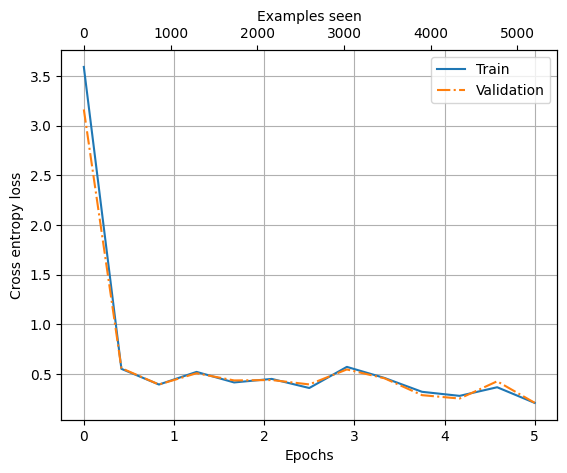

In [17]:
import matplotlib.pylab as plt


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

fig, ax = plt.subplots()

ax.plot(
    epochs_tensor,
    train_losses,
    label='Train'
)

ax.plot(
    epochs_tensor,
    val_losses,
    '-.',
    label='Validation'
)

ax2 = ax.twiny()
ax2.plot(
    examples_seen_tensor,
    train_losses,
    alpha=0
)

ax.grid()
ax.set_ylabel('Cross entropy loss')
ax.set_xlabel('Epochs')
ax2.set_xlabel('Examples seen')
ax.legend()

In [18]:
train_accuracy = calc_accuracy_loader(model, train_loader, device)
val_accuracy = calc_accuracy_loader(model, val_loader, device)
test_accuracy = calc_accuracy_loader(model, test_loader, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 90.96%
Validation accuracy: 91.52%
Test accuracy: 88.39%


So we get accuracies in the order of 90 % after LoRA fine-tuning. This is lower than what we achieved when fine-tuning all parameters in the last transformer block. Yet, this still demonstrates that the LoRA approach works.